In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

In [23]:
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/prepared_data.csv')

if 'SalePrice_log' in df.columns:
    df = df.drop('SalePrice_log', axis=1)

X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2234, 252)
Test size: (559, 252)


In [24]:
if 'SalePrice_log' in df.columns:
    print("WARNING: Leakage detected! SalePrice_log is present.")
else:
    print("Good! No leakage detected.")

Good! No leakage detected.


In [26]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  RMSE : ${rmse:,.0f}")
    print(f"  MAE  : ${mae:,.0f}")
    print(f"  R²   : {r2:.4f}")
    
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Predictions': y_pred}

In [27]:
results = []

lr  = evaluate_model("Linear Regression",  LinearRegression(),           X_train, X_test, y_train, y_test)
rf  = evaluate_model("Random Forest",       RandomForestRegressor(random_state=42), X_train, X_test, y_train, y_test)
xgb = evaluate_model("XGBoost",             XGBRegressor(random_state=42, verbosity=0), X_train, X_test, y_train, y_test)

results = [lr, rf, xgb]


  Linear Regression
  RMSE : $33,671
  MAE  : $14,327
  R²   : 0.6951

  Random Forest
  RMSE : $19,950
  MAE  : $13,899
  R²   : 0.8930

  XGBoost
  RMSE : $19,271
  MAE  : $13,277
  R²   : 0.9001


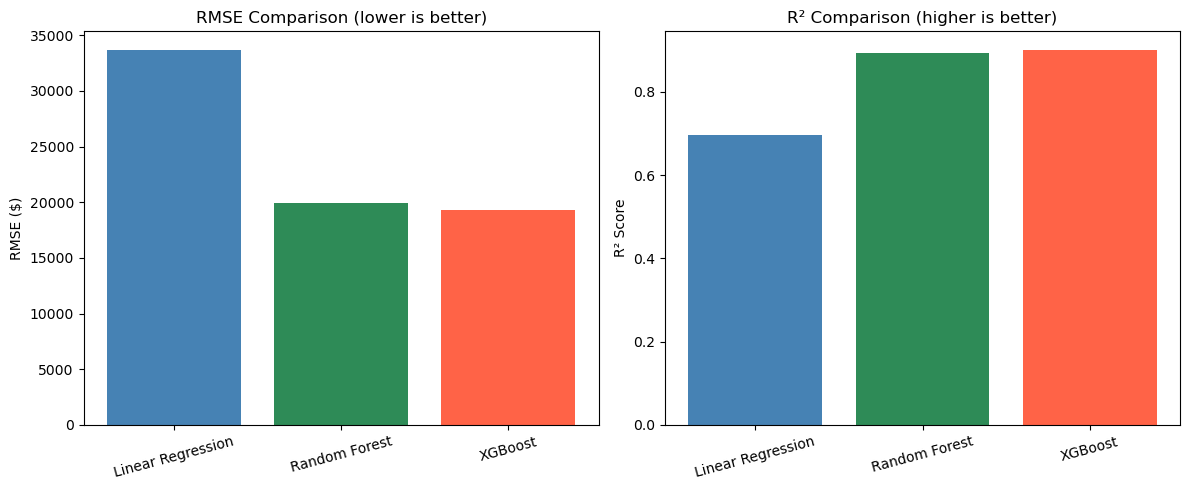

In [28]:
compare_df = pd.DataFrame([{
    'Model': r['Model'], 'RMSE': r['RMSE'], 'R2': r['R2']
} for r in results])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(compare_df['Model'], compare_df['RMSE'], color=['steelblue', 'seagreen', 'tomato'])
axes[0].set_title('RMSE Comparison (lower is better)')
axes[0].set_ylabel('RMSE ($)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(compare_df['Model'], compare_df['R2'], color=['steelblue', 'seagreen', 'tomato'])
axes[1].set_title('R² Comparison (higher is better)')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [29]:
from sklearn.model_selection import cross_val_score

cv_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(random_state=42),
    'XGBoost':           XGBRegressor(random_state=42, verbosity=0)
}

print("5-Fold Cross-Validation RMSE:\n")
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='neg_root_mean_squared_error')
    rmse_scores = -scores
    print(f"{name}: Mean RMSE = ${rmse_scores.mean():,.0f}  ±  ${rmse_scores.std():,.0f}")

5-Fold Cross-Validation RMSE:

Linear Regression: Mean RMSE = $27,399  ±  $6,312
Random Forest: Mean RMSE = $20,649  ±  $737
XGBoost: Mean RMSE = $19,331  ±  $876


In [30]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)
print("\nBest RF Params:", rf_grid.best_params_)
print(f"Best CV RMSE:  ${-rf_grid.best_score_:,.0f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best RF Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE:  $20,814


In [31]:
xgb_params = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)
print("\nBest XGB Params:", xgb_grid.best_params_)
print(f"Best CV RMSE:   ${-xgb_grid.best_score_:,.0f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best XGB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV RMSE:   $18,360


In [32]:
tuned_rf  = evaluate_model("Tuned Random Forest", rf_grid.best_estimator_,  X_train, X_test, y_train, y_test)
tuned_xgb = evaluate_model("Tuned XGBoost",       xgb_grid.best_estimator_, X_train, X_test, y_train, y_test)


  Tuned Random Forest
  RMSE : $19,847
  MAE  : $13,844
  R²   : 0.8941

  Tuned XGBoost
  RMSE : $17,490
  MAE  : $12,202
  R²   : 0.9177


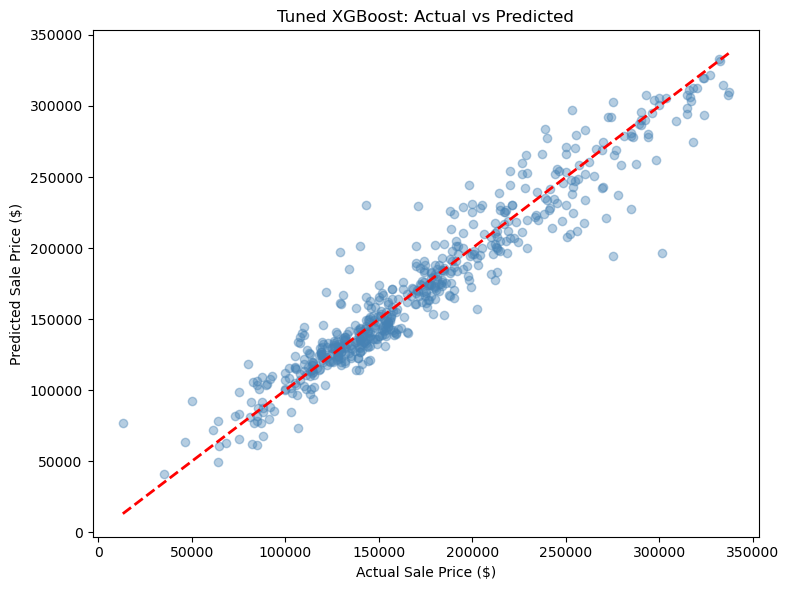

In [33]:
# Use whichever tuned model had lower RMSE
best_name  = "Tuned XGBoost"
best_preds = tuned_xgb['Predictions']

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_preds, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.title(f'{best_name}: Actual vs Predicted')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

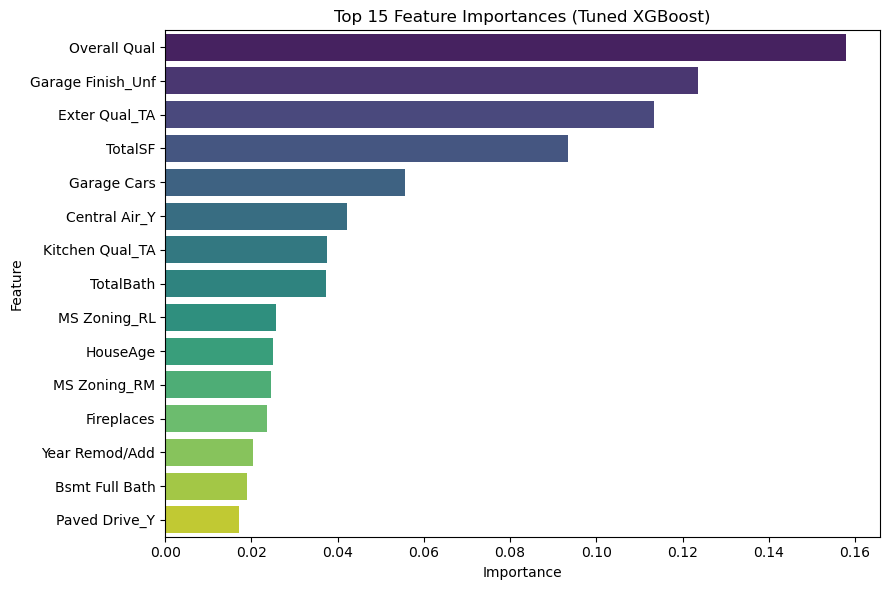

In [34]:
importances = xgb_grid.best_estimator_.feature_importances_
feat_df = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (Tuned XGBoost)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [36]:
import joblib
joblib.dump(xgb_grid.best_estimator_, r'C:/Users/khage/Documents/house price prediction/notebooks/best_model_xgb.pkl')
print("Model saved!")
print("Best params:", xgb_grid.best_estimator_.get_params())

Model saved!
Best params: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': 0}


In [37]:
print("Best params found:", xgb_grid.best_params_)
print("Best RMSE:", xgb_grid.best_score_)

Best params found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best RMSE: -18360.095703125
